# ============================================================
# Experiment: Implement Keras MLP for Multiclass classification.
#
# Name      : Divyabhanu Rana
# Roll No.  : 24215209
# Class     : 5-BDA
# Course    : Artificial Neural Networks Lab
# Date      : 27/07/2026
# ============================================================

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Classes:", iris.target_names)

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3542 - loss: 1.2169 - val_accuracy: 0.2500 - val_loss: 1.3127
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3542 - loss: 1.1406 - val_accuracy: 0.2500 - val_loss: 1.2348
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3646 - loss: 1.0723 - val_accuracy: 0.2500 - val_loss: 1.1700
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3750 - loss: 1.0204 - val_accuracy: 0.2500 - val_loss: 1.1166
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3958 - loss: 0.9774 - val_accuracy: 0.2500 - val_loss: 1.0732
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4688 - loss: 0.9437 - val_accuracy: 0.2500 - val_loss: 1.0395
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4896 - loss: 0.9155 - val_accuracy: 0.2500 - val_loss: 1.0092
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5104 - loss: 0.8907 - val_accuracy: 0.2500 - v

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9333 - loss: 0.2020

Test Accuracy: 0.9333


In [10]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print("\nClassification Report\n")
print(classification_report(y_test, predicted_classes, target_names=iris.target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.80      0.89        10
   virginica       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [11]:
cm = confusion_matrix(y_test, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

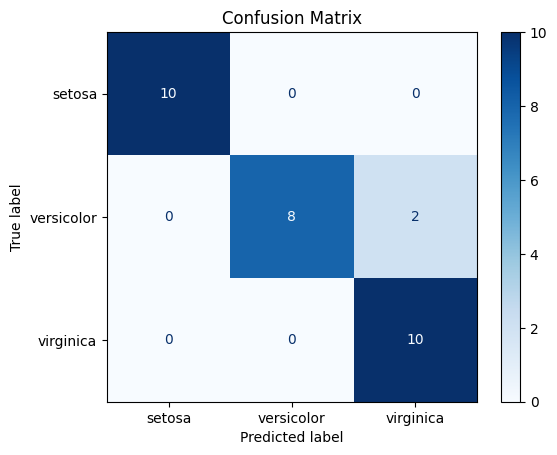

In [12]:
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

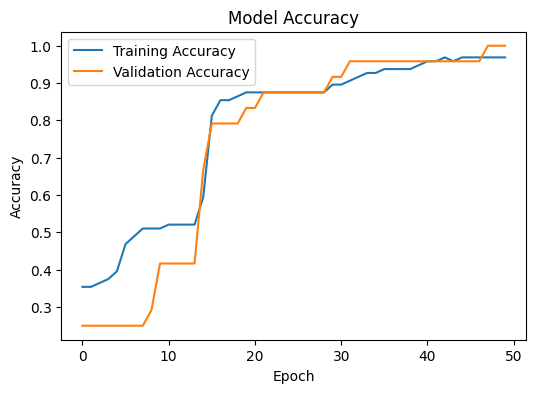

In [13]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

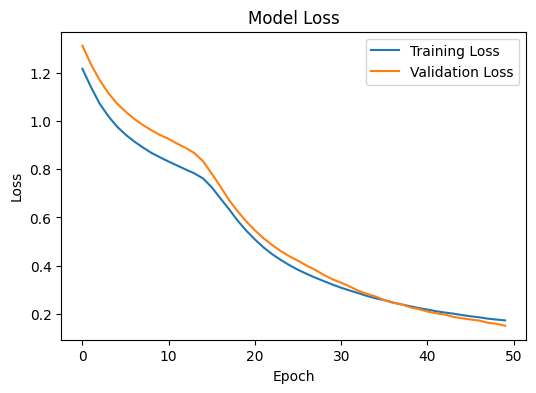

In [14]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()